In [2]:
#  Import Libraries
# ---------------------------
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#  Create Database + Table
# ---------------------------
# This creates a local SQLite file in the Colab environment
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [4]:
# Create a simple sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [5]:
# Insert Sample Data
# ---------------------------
sample_data = [
    ("Laptop", 5, 60000),
    ("Mouse", 20, 500),
    ("Keyboard", 10, 1500),
    ("Monitor", 8, 10000),
    ("Headphones", 12, 2000)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

In [6]:
# Run SQL Query inside Python
# ---------------------------
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

In [7]:
#Display the Results
# ---------------------------
print("📊 Basic Sales Summary:\n")
print(df)

📊 Basic Sales Summary:

      product  total_qty   revenue
0  Headphones         12   24000.0
1    Keyboard         10   15000.0
2      Laptop          5  300000.0
3     Monitor          8   80000.0
4       Mouse         20   10000.0


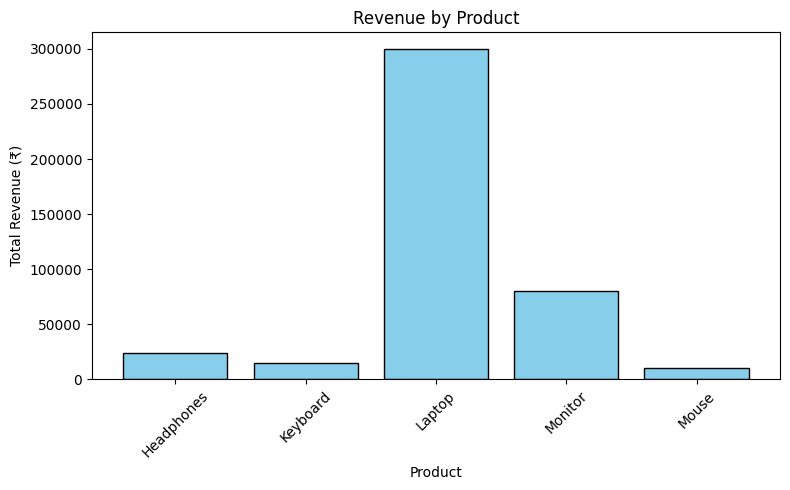

In [8]:
#Plot Simple Bar Chart
# ---------------------------
plt.figure(figsize=(8,5))
plt.bar(df['product'], df['revenue'], color='skyblue', edgecolor='black')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()